# CSW 프로젝트 EDA ②: CSW 기준 EDA → Kirby Index와의 관계

> **선행**: `pitcher_count_eda.ipynb` (EDA ① — 데이터 가져오기 + 투수의 수)
> **데이터**: `data/statcast_2017_2019_raw_csw.parquet` + `reports/kirby_index/kirby_index_by_season.csv`

**흐름**

1. **CSW 기준 EDA**: 라벨 분해(called/whiff) → 카운트별 → 구종별 → 투수별 분포·안정성
2. **Kirby Index ↔ CSW**: 같은 시즌 상관(피어슨·스피어만) → 다음 시즌 예측 상관 → 과거 CSW율 대비 추가 가치(부분상관)

**핵심 질문**: CSW는 어디서 오는가(상황·구종·투수), 그리고 투수의 **커맨드 반복성(Kirby Index)** 이
CSW 예측에 실제로 도움이 되는가.

## 0. 환경 준비 + 데이터 가져오기 (EDA ①과 같은 패턴)

이번에는 CSW 분석에 필요한 열로 바꿔 로드합니다: 카운트(`balls`,`strikes`), 결과(`description`), 구종, 투수, 라벨.

In [1]:
import importlib.util, subprocess, sys
for pkg in ['pandas', 'numpy', 'pyarrow', 'matplotlib', 'scipy']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

def set_korean_font():
    from matplotlib import font_manager
    names = {f.name for f in font_manager.fontManager.ttflist}
    for cand in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'NanumBarunGothic']:
        if cand in names:
            matplotlib.rcParams['font.family'] = cand
            return cand
    return None

font = set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False

DATA_PATH = Path('data/statcast_2017_2019_raw_csw.parquet')
KIRBY_PATH = Path('reports/kirby_index/kirby_index_by_season.csv')
assert DATA_PATH.exists() and KIRBY_PATH.exists(), '프로젝트 루트에서 실행했는지 확인'

USE_COLS = ['game_year', 'game_type', 'pitcher', 'player_name',
            'pitch_type', 'balls', 'strikes', 'description', 'is_csw']
df = pd.read_parquet(DATA_PATH, columns=USE_COLS)
for c in ['game_type', 'pitch_type', 'description', 'player_name']:
    df[c] = df[c].astype('category')

EXPECTED_ROWS = 2_201_095  # EDA ①에서 검증한 값
assert len(df) == EXPECTED_ROWS
print(f'로드: {len(df):,}행 | 전체 CSW율 {df.is_csw.mean():.1%}')

로드: 2,201,095행 | 전체 CSW율 27.4%


## 1. CSW 기준 EDA

### 1-1. 라벨 분해 — CSW는 무엇으로 이루어져 있나

`is_csw` = called_strike(콜드 스트라이크) + swinging_strike(+blocked)(헛스윙).
두 성분은 성격이 다릅니다 — **called는 커맨드(존 경계 공략)**, **whiff는 구위(stuff)** 와 더 관련된다고 알려져 있습니다.
이 구분이 뒤의 Kirby Index 분석에서 중요해집니다.

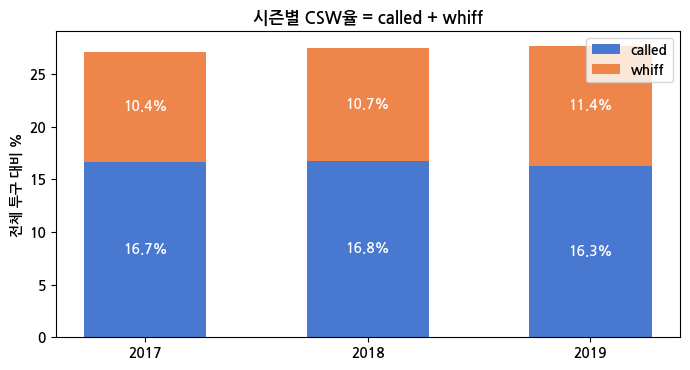

전체 투구 중: called 16.6% + whiff 10.8% = CSW 27.4%


In [2]:
df['csw_part'] = np.select(
    [df['description'].eq('called_strike'),
     df['description'].isin(['swinging_strike', 'swinging_strike_blocked'])],
    ['called', 'whiff'], default='non_csw')

comp = (df.groupby(['game_year', 'csw_part'], observed=True).size()
        .unstack()[['called', 'whiff', 'non_csw']])
comp_rate = comp.div(comp.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 3.8))
bottom = np.zeros(3)
for part, color in [('called', '#4878cf'), ('whiff', '#ee854a')]:
    v = comp_rate[part] * 100
    ax.bar(comp_rate.index.astype(str), v, bottom=bottom, label=part, color=color, width=0.55)
    for i, (b, x) in enumerate(zip(bottom, v)):
        ax.text(i, b + x / 2, f'{x:.1f}%', ha='center', va='center', color='w', fontsize=10)
    bottom += v
ax.set_title('시즌별 CSW율 = called + whiff')
ax.set_ylabel('전체 투구 대비 %')
ax.legend()
plt.tight_layout(); plt.show()

print('전체 투구 중: called {:.1%} + whiff {:.1%} = CSW {:.1%}'.format(
    (df.csw_part == 'called').mean(), (df.csw_part == 'whiff').mean(), df.is_csw.mean()))

### 1-2. 카운트별 CSW율 — 상황이 CSW를 크게 좌우한다

모델 피처 중 카운트가 왜 중요한지 눈으로 확인합니다. 타자는 2스트라이크에서 존을 지키려고 스윙을 늘리므로
called는 급감하고 whiff 비중이 커집니다. 반대로 3-0에서는 방망이가 거의 나오지 않습니다.

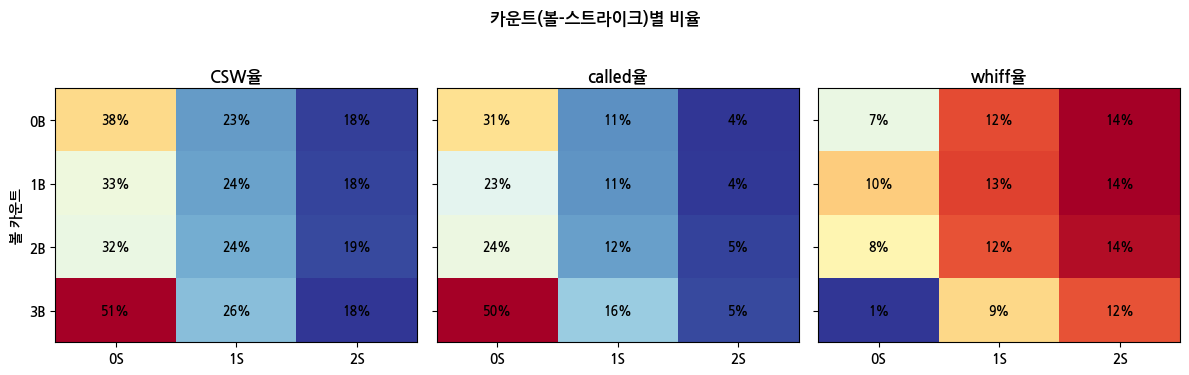

In [3]:
cnt = df[df.balls.le(3) & df.strikes.le(2)]
mats = {}
for name, col in [('CSW율', 'is_csw'),
                  ('called율', None), ('whiff율', None)]:
    if col:
        m = cnt.pivot_table(index='balls', columns='strikes', values=col, aggfunc='mean')
    else:
        key = 'called' if 'called' in name else 'whiff'
        m = (cnt.assign(v=cnt.csw_part.eq(key))
             .pivot_table(index='balls', columns='strikes', values='v', aggfunc='mean'))
    mats[name] = m

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, (name, m) in zip(axes, mats.items()):
    im = ax.imshow(m.values, cmap='RdYlBu_r', aspect='auto')
    ax.set_xticks(range(3), [f'{s}S' for s in m.columns])
    ax.set_yticks(range(4), [f'{b}B' for b in m.index])
    ax.set_title(name)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            ax.text(j, i, f'{m.values[i, j]:.0%}', ha='center', va='center', fontsize=9)
axes[0].set_ylabel('볼 카운트')
fig.suptitle('카운트(볼-스트라이크)별 비율', y=1.03)
plt.tight_layout(); plt.show()

### 1-3. 구종별 CSW율 — whiff는 변화구, called는 패스트볼

구종은 **현재 투구 정보라 모델 입력 금지**지만, 투수의 구종 '구성'이 CSW 이력으로 스며드는 구조를 이해하는 데 필요합니다.

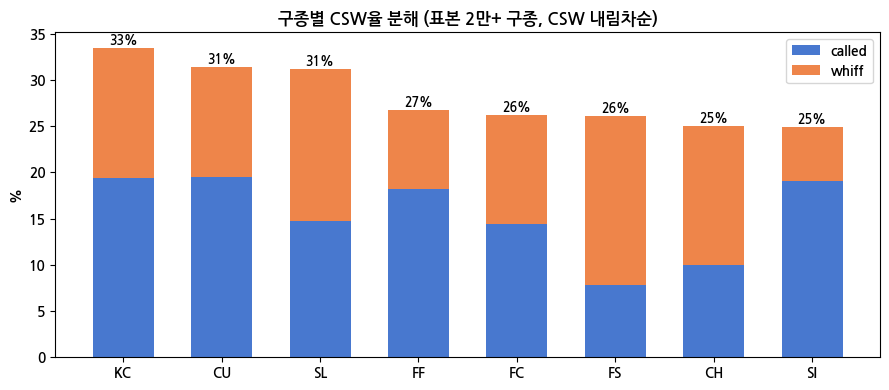

,투구수,csw,called,whiff
pitch_type,,,,
KC,"59,667",33.5%,19.4%,14.1%
CU,"171,257",31.4%,19.4%,12.0%
SL,"342,520",31.2%,14.7%,16.5%
FF,"767,983",26.7%,18.2%,8.5%
FC,"131,750",26.2%,14.4%,11.8%
FS,"34,509",26.1%,7.9%,18.3%
CH,"224,656",25.0%,9.9%,15.0%
SI,"408,756",24.9%,19.0%,5.9%


In [4]:
top_pt = df.pitch_type.value_counts()
top_pt = top_pt[top_pt >= 20_000].index.tolist()  # 표본 2만 구 이상 구종만

pt = (df[df.pitch_type.isin(top_pt)]
      .groupby('pitch_type', observed=True)
      .agg(투구수=('is_csw', 'size'), csw=('is_csw', 'mean'),
           called=('csw_part', lambda s: s.eq('called').mean()),
           whiff=('csw_part', lambda s: s.eq('whiff').mean()))
      .sort_values('csw', ascending=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(pt))
ax.bar(x, pt.called * 100, label='called', color='#4878cf', width=0.62)
ax.bar(x, pt.whiff * 100, bottom=pt.called * 100, label='whiff', color='#ee854a', width=0.62)
for i, (c, w) in enumerate(zip(pt.called, pt.whiff)):
    ax.text(i, (c + w) * 100 + 0.4, f'{(c + w):.0%}', ha='center', fontsize=9)
ax.set_xticks(x, pt.index)
ax.set_ylabel('%')
ax.set_title('구종별 CSW율 분해 (표본 2만+ 구종, CSW 내림차순)')
ax.legend()
plt.tight_layout(); plt.show()

pt.style.format({'투구수': '{:,}', 'csw': '{:.1%}', 'called': '{:.1%}', 'whiff': '{:.1%}'})

### 1-4. 투수별 CSW율 — 분포와 소표본 불안정성 (funnel)

EDA ①에서 본 표본 비대칭이 여기서 문제가 됩니다: 투구 수가 적은 투수의 CSW율은 극단값이 많아
**그대로 피처로 쓰면 노이즈**입니다(모델에서 expanding + last100을 쓰는 이유).

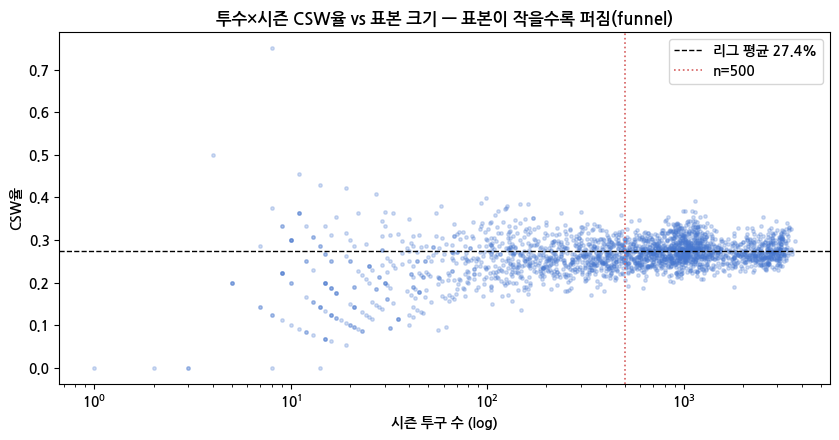

n≥500 투수×시즌: 1,413건 | CSW율 SD: 전체 0.047 → n≥500만 0.028
n≥500 CSW율 상위 5:
 game_year      player_name    n      csw
      2017   Kimbrel, Craig 1148 0.391115
      2017   Miller, Andrew  987 0.368794
      2017   Jansen, Kenley 1012 0.368577
      2017 Betances, Dellin 1106 0.367089
      2018 Betances, Dellin 1143 0.364829


In [5]:
pcsw = (df[df.game_type == 'R']
        .groupby(['game_year', 'pitcher'], observed=True)
        .agg(n=('is_csw', 'size'), csw=('is_csw', 'mean'),
             called=('csw_part', lambda s: s.eq('called').mean()),
             whiff=('csw_part', lambda s: s.eq('whiff').mean()))
        .reset_index())
league = df.is_csw.mean()

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.scatter(pcsw.n, pcsw.csw, s=6, alpha=0.25, color='#4878cf')
ax.axhline(league, color='k', ls='--', lw=1, label=f'리그 평균 {league:.1%}')
ax.axvline(500, color='#d65f5f', ls=':', lw=1.2, label='n=500')
ax.set_xscale('log')
ax.set_xlabel('시즌 투구 수 (log)')
ax.set_ylabel('CSW율')
ax.set_title('투수×시즌 CSW율 vs 표본 크기 — 표본이 작을수록 퍼짐(funnel)')
ax.legend()
plt.tight_layout(); plt.show()

big = pcsw[pcsw.n >= 500]
print(f'n≥500 투수×시즌: {len(big):,}건 | CSW율 SD: 전체 {pcsw.csw.std():.3f} → n≥500만 {big.csw.std():.3f}')
print('n≥500 CSW율 상위 5:')
top5 = big.nlargest(5, 'csw').merge(
    df[['pitcher', 'player_name']].drop_duplicates('pitcher'), on='pitcher')
print(top5[['game_year', 'player_name', 'n', 'csw']].to_string(index=False))

### 1-5. 투수 CSW율은 시즌이 바뀌어도 유지되나 (안정성)

CSW율이 시즌 간 상관이 높다면 "투수 고유의 실력"에 가깝고, 과거 CSW 이력 피처가 유효하다는 근거가 됩니다.
동시에 이 값은 **Kirby Index 같은 다른 투수 지표가 넘어야 할 기준선**이기도 합니다.

,구간,투수 수,pearson_r,r²,p값
0,2017→2018,321,0.648,0.420,1.3e-39
1,2018→2019,325,0.642,0.412,3.5e-39


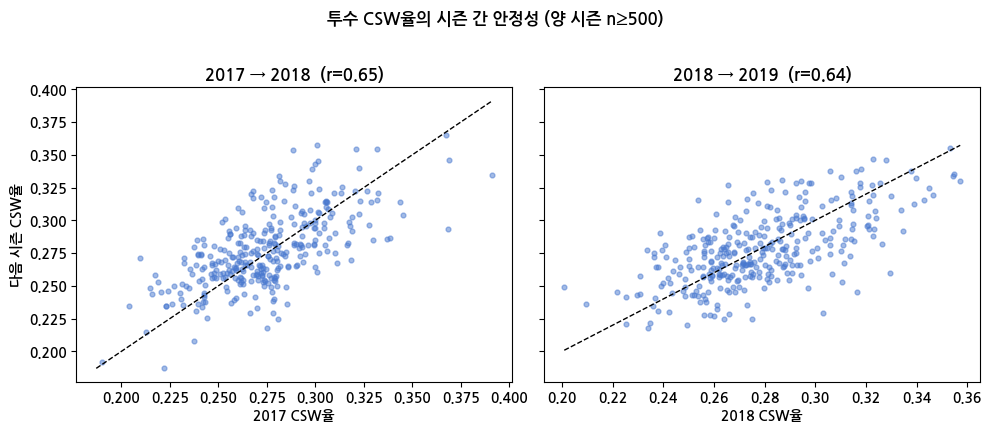

In [6]:
wide = pcsw[pcsw.n >= 500].pivot(index='pitcher', columns='game_year', values='csw')

stab_rows = []
for y1, y2 in [(2017, 2018), (2018, 2019)]:
    pair = wide[[y1, y2]].dropna()
    r, p = stats.pearsonr(pair[y1], pair[y2])
    stab_rows.append({'구간': f'{y1}→{y2}', '투수 수': len(pair),
                      'pearson_r': round(r, 3), 'r²': round(r * r, 3), 'p값': f'{p:.1e}'})
stab = pd.DataFrame(stab_rows)
display(stab)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, (y1, y2) in zip(axes, [(2017, 2018), (2018, 2019)]):
    pair = wide[[y1, y2]].dropna()
    ax.scatter(pair[y1], pair[y2], s=12, alpha=0.5, color='#4878cf')
    lo, hi = pair.values.min(), pair.values.max()
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    r = stats.pearsonr(pair[y1], pair[y2])[0]
    ax.set_title(f'{y1} → {y2}  (r={r:.2f})')
    ax.set_xlabel(f'{y1} CSW율')
axes[0].set_ylabel('다음 시즌 CSW율')
fig.suptitle('투수 CSW율의 시즌 간 안정성 (양 시즌 n≥500)', y=1.02)
plt.tight_layout(); plt.show()

---
## 2. Kirby Index가 CSW 예측에 도움이 되는가

**Kirby Index 복습**: 포심(FF) 릴리스의 반복성 — {수직/수평 릴리스 각도, 릴리스 좌표} 4개 SD를
시즌 내 백분위로 바꿔 가중평균한 값. **높을수록 릴리스가 일정 = 커맨드가 좋다**로 해석 (0~1).

**검증 설계** — 세 단계로 강도를 올립니다:

| 단계 | 질문 | 방법 |
|---|---|---|
| ① 같은 시즌 | 커맨드 좋은 투수가 CSW도 높나? | 피어슨·스피어만 상관 |
| ② 다음 시즌 | 올해 Kirby로 **내년** CSW를 알 수 있나? (예측 방향) | Kirby(t) vs CSW(t+1) |
| ③ 추가 가치 | 이미 아는 과거 CSW율 **너머의** 정보가 있나? | CSW(t) 통제 후 부분상관 |

②·③이 진짜 질문입니다 — 모델은 항상 과거 정보만으로 예측하기 때문.

### 2-1. Kirby 테이블 로드 + 투수×시즌 CSW와 결합

In [7]:
kirby = pd.read_csv(KIRBY_PATH)[['game_year', 'pitcher', 'player_name', 'kirby_index', 'n_pitches']]
print(f'Kirby 테이블: {len(kirby):,}건 (시즌×투수, 정규시즌 FF≥125구)')

# FF만 기준 CSW율도 추가 (Kirby가 FF 기반이므로 같은 조건으로도 비교)
ff = df[(df.pitch_type == 'FF') & (df.game_type == 'R')]
pcsw_ff = (ff.groupby(['game_year', 'pitcher'], observed=True)
           .agg(n_ff=('is_csw', 'size'), csw_ff=('is_csw', 'mean'),
                called_ff=('csw_part', lambda s: s.eq('called').mean()),
                whiff_ff=('csw_part', lambda s: s.eq('whiff').mean()))
           .reset_index())

m = (kirby
     .merge(pcsw, on=['game_year', 'pitcher'], how='inner')      # 전체 투구 CSW
     .merge(pcsw_ff, on=['game_year', 'pitcher'], how='inner'))  # FF만 CSW
print(f'결합 후: {len(m):,}건 | 열: {list(m.columns)}')
m.head(3)

Kirby 테이블: 1,397건 (시즌×투수, 정규시즌 FF≥125구)


결합 후: 1,397건 | 열: ['game_year', 'pitcher', 'player_name', 'kirby_index', 'n_pitches', 'n', 'csw', 'called', 'whiff', 'n_ff', 'csw_ff', 'called_ff', 'whiff_ff']


,game_year,pitcher,player_name,kirby_index,n_pitches,n,csw,called,whiff,n_ff,csw_ff,called_ff,whiff_ff
0,2017,472610,"García, Luis",0.882678,319,1015,0.253202,0.135961,0.117241,319,0.219436,0.166144,0.053292
1,2018,594798,"deGrom, Jacob",0.881394,1374,3221,0.314499,0.163614,0.150885,1374,0.320961,0.158661,0.162300
2,2019,605359,"Marshall, Evan",0.873943,195,842,0.266033,0.153207,0.112827,195,0.205128,0.153846,0.051282


### 2-2. ① 같은 시즌 — Kirby vs CSW (피어슨·스피어만)

전체 CSW뿐 아니라 **called/whiff로 쪼개서** 봅니다. 커맨드 가설이 맞다면
whiff(구위)보다 **called(존 경계 공략)** 쪽 상관이 커야 합니다.

,pearson_r,p(pearson),spearman_ρ,p(spearman)
대상,,,,
전체 CSW율,0.088,9.9e-04,0.077,4.0e-03
전체 called율,0.095,3.5e-04,0.099,2.0e-04
전체 whiff율,0.024,3.6e-01,0.009,7.4e-01
FF CSW율,0.254,4.5e-22,0.248,5.5e-21
FF called율,0.131,8.4e-07,0.125,2.7e-06
FF whiff율,0.150,1.7e-08,0.144,6.0e-08


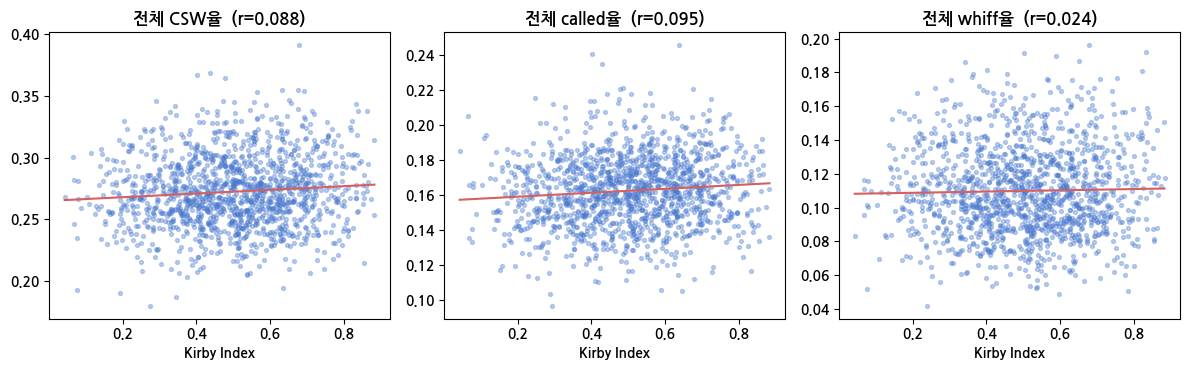

In [8]:
targets = [('csw', '전체 CSW율'), ('called', '전체 called율'), ('whiff', '전체 whiff율'),
           ('csw_ff', 'FF CSW율'), ('called_ff', 'FF called율'), ('whiff_ff', 'FF whiff율')]

rows = []
for col, label in targets:
    r_p, p_p = stats.pearsonr(m.kirby_index, m[col])
    r_s, p_s = stats.spearmanr(m.kirby_index, m[col])
    rows.append({'대상': label, 'pearson_r': round(r_p, 3), 'p(pearson)': f'{p_p:.1e}',
                 'spearman_ρ': round(r_s, 3), 'p(spearman)': f'{p_s:.1e}'})
same_season = pd.DataFrame(rows).set_index('대상')
display(same_season)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (col, label) in zip(axes, [('csw', '전체 CSW율'), ('called', '전체 called율'), ('whiff', '전체 whiff율')]):
    ax.scatter(m.kirby_index, m[col], s=8, alpha=0.35, color='#4878cf')
    b, a = np.polyfit(m.kirby_index, m[col], 1)
    xs = np.linspace(m.kirby_index.min(), m.kirby_index.max(), 50)
    ax.plot(xs, a + b * xs, color='#d65f5f', lw=1.5)
    r = stats.pearsonr(m.kirby_index, m[col])[0]
    ax.set_title(f'{label}  (r={r:.3f})')
    ax.set_xlabel('Kirby Index')
plt.tight_layout(); plt.show()

### 2-3. ② 다음 시즌 예측 — Kirby(t) vs CSW(t+1)

예측 모델의 상황을 흉내 냅니다: **올해의 Kirby Index만 들고 내년 CSW율을 맞혀야 한다면?**
비교 기준으로 '올해 CSW율로 내년 CSW율 예측'(가장 단순한 이력 피처)도 함께 계산합니다.

표본: 594건 (Kirby(t) 보유 & 다음 시즌 n≥500)


타깃,CSW(t+1),called(t+1),whiff(t+1)
피처,,,
Kirby(t),0.039,0.092,-0.024
당해 CSW율(t),0.625,0.227,0.512


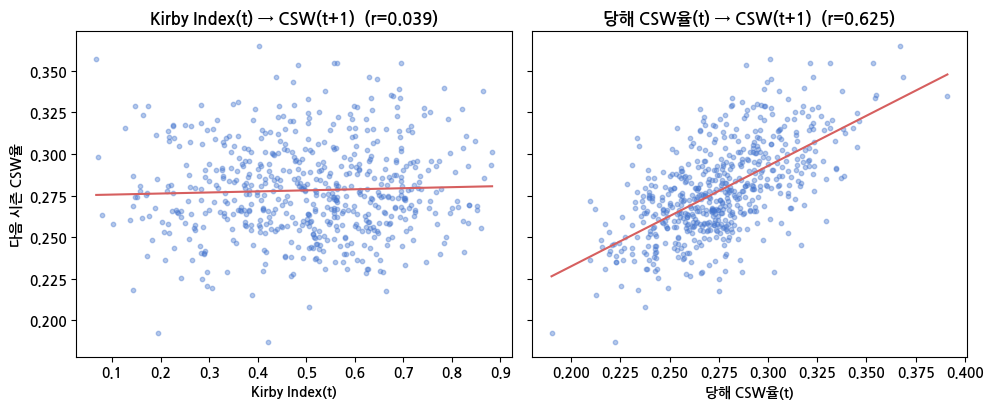

In [9]:
nxt = m[['game_year', 'pitcher', 'kirby_index', 'csw', 'called', 'whiff']].copy()
nxt['next_year'] = nxt.game_year + 1
fut = pcsw[pcsw.n >= 500][['game_year', 'pitcher', 'csw', 'called', 'whiff']].rename(
    columns={'game_year': 'next_year', 'csw': 'csw_next', 'called': 'called_next', 'whiff': 'whiff_next'})
pred = nxt.merge(fut, on=['next_year', 'pitcher'], how='inner')
print(f'표본: {len(pred):,}건 (Kirby(t) 보유 & 다음 시즌 n≥500)')

rows = []
for feat, feat_label in [('kirby_index', 'Kirby(t)'), ('csw', '당해 CSW율(t)')]:
    for tgt, tgt_label in [('csw_next', 'CSW(t+1)'), ('called_next', 'called(t+1)'), ('whiff_next', 'whiff(t+1)')]:
        r, p = stats.pearsonr(pred[feat], pred[tgt])
        rows.append({'피처': feat_label, '타깃': tgt_label, 'pearson_r': round(r, 3), 'p값': f'{p:.1e}'})
pred_tbl = pd.DataFrame(rows).pivot(index='피처', columns='타깃', values='pearson_r')
display(pred_tbl)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, feat, label in [(axes[0], 'kirby_index', 'Kirby Index(t)'), (axes[1], 'csw', '당해 CSW율(t)')]:
    ax.scatter(pred[feat], pred.csw_next, s=10, alpha=0.4, color='#4878cf')
    b, a = np.polyfit(pred[feat], pred.csw_next, 1)
    xs = np.linspace(pred[feat].min(), pred[feat].max(), 50)
    ax.plot(xs, a + b * xs, color='#d65f5f', lw=1.5)
    r = stats.pearsonr(pred[feat], pred.csw_next)[0]
    ax.set_title(f'{label} → CSW(t+1)  (r={r:.3f})')
    ax.set_xlabel(label)
axes[0].set_ylabel('다음 시즌 CSW율')
plt.tight_layout(); plt.show()

### 2-4. ③ 추가 가치 — 과거 CSW율을 통제한 부분상관

모델에는 이미 과거 CSW 이력 피처가 있으므로, Kirby가 의미 있으려면
**"당해 CSW율이 같은 투수들 사이에서도" Kirby가 높으면 내년 CSW가 높아야** 합니다.
방법: CSW(t)로 양쪽을 회귀한 잔차끼리 피어슨 상관(= 부분상관).

In [10]:
def partial_corr(x, y, control):
    rx = x - np.poly1d(np.polyfit(control, x, 1))(control)
    ry = y - np.poly1d(np.polyfit(control, y, 1))(control)
    return stats.pearsonr(rx, ry)

rows = []
for tgt, label in [('csw_next', 'CSW(t+1)'), ('called_next', 'called(t+1)'), ('whiff_next', 'whiff(t+1)')]:
    r_raw, p_raw = stats.pearsonr(pred.kirby_index, pred[tgt])
    r_par, p_par = partial_corr(pred.kirby_index.to_numpy(), pred[tgt].to_numpy(), pred.csw.to_numpy())
    rows.append({'타깃': label, '원상관 r': round(r_raw, 3),
                 '부분상관 r (CSW(t) 통제)': round(r_par, 3), 'p(부분)': f'{p_par:.2f}'})
partial_tbl = pd.DataFrame(rows).set_index('타깃')
display(partial_tbl)

# 직관 확인: Kirby 5분위별 다음 시즌 평균 CSW
pred['kirby_q'] = pd.qcut(pred.kirby_index, 5, labels=['Q1(최하)', 'Q2', 'Q3', 'Q4', 'Q5(최상)'])
quint = pred.groupby('kirby_q', observed=True).agg(
    표본=('csw_next', 'size'), 다음시즌_CSW=('csw_next', 'mean'),
    다음시즌_called=('called_next', 'mean'), 다음시즌_whiff=('whiff_next', 'mean'))
display(quint.style.format({'다음시즌_CSW': '{:.1%}', '다음시즌_called': '{:.1%}', '다음시즌_whiff': '{:.1%}'}))

,원상관 r,부분상관 r (CSW(t) 통제),p(부분)
타깃,,,
CSW(t+1),0.039,-0.022,0.59
called(t+1),0.092,0.074,0.07
whiff(t+1),-0.024,-0.083,0.04


,표본,다음시즌_CSW,다음시즌_called,다음시즌_whiff
kirby_q,,,,
Q1(최하),119,27.7%,16.1%,11.6%
Q2,119,27.9%,16.7%,11.2%
Q3,118,27.7%,16.4%,11.2%
Q4,119,27.6%,16.6%,11.0%
Q5(최상),119,28.3%,16.6%,11.7%


---
## 3. 정리 — Kirby Index는 CSW 예측에 도움이 되는가?

**① 같은 시즌 (n=1,397 시즌×투수)**

- Kirby ↔ 전체 CSW율: **r=0.088** (p<0.001) — 유의하지만 약함. 분해하면 called r=0.095 > whiff r=0.024(비유의) → **"커맨드는 called 쪽"** 가설과 방향 일치.
- Kirby ↔ **FF만** CSW율: **r=0.254** — 같은 구종(포심) 안에서는 관계가 3배 뚜렷. Kirby가 FF 기반 지표이므로 자연스러운 결과.

**② 다음 시즌 예측 (n=594)**

- Kirby(t) → CSW(t+1): **r=0.039 (비유의)**. 반면 당해 CSW율(t) → CSW(t+1): **r=0.625**.
- 즉 시즌 단위 Kirby 단독으로는 내년 CSW를 거의 설명하지 못하고, 단순 과거 CSW율이 압도적으로 강한 예측자.

**③ 추가 가치 (CSW(t) 통제 부분상관)**

- CSW(t+1): r=−0.022 (p=0.59) → **과거 CSW율 너머의 추가 정보 없음**
- 다만 분해하면 called(t+1) **+0.074** (p=0.07) / whiff(t+1) **−0.083** (p=0.04)로 방향이 갈려 상쇄 — 커맨드 좋은 투수는 called를 약간 더 얻고 whiff는 오히려 덜 얻는 경향.

**결론과 시사점**

1. 시즌 집계 Kirby Index를 **CSW 예측 피처로 그대로 쓰는 것은 근거 부족** (부분상관 ≈ 0).
2. 그러나 CSW 이력 피처는 강력함이 재확인됨 (시즌 간 r≈0.64~0.65, n≥500) — expanding/last100 이력 피처 설계가 옳은 방향.
3. 모델에서 cmd_ff_* (rolling 40구, 투구 단위)가 +0.008 AUC를 낸 것과 모순 아님 — **시즌 집계가 아니라 "최근 폼" 수준의 세밀한 커맨드 신호**가 유효하다는 해석. called/whiff 부호가 갈리는 것도 단일 CSW 타깃보다 분해 타깃(또는 상호작용)이 나을 수 있음을 시사.
4. 회의 안건 제안: ⓐ cmd 피처는 유지하되 시즌 Kirby는 피처에서 제외 ⓑ called/whiff 분리 예측(2-head) 검토 ⓒ FF 외 구종으로 Kirby 확장 시 재검증(E단계).

**한계**: 시즌×투수 수준 선형 상관만 봄(투구 단위 비선형 기여는 ablation이 담당), t+1 표본 594건, n≥500 필터로 생존 편향 가능.